# Experimenting with PyTorch

For using PyTorch you can either use your own Computer or [Google Colab](https://colab.research.google.com/).

You need to install the [PyTorch](https://pytorch.org/) package which comes with some extra dependencies.

Install the following packages for this notebook:
- **PyTorch**
- **torchvision**
- **tqdm**
- **matplotlib**

If your computer is equpped with a GPU you can also install the GPU version of PyTorch. Otherwise install the CPU version, which is smaller in size and enough for the tasks of this practical.

For using the GPU version you need to fullfill some prerequisites first, which are a little time consuming.
- Make sure that your graphics card is new enough to handle the PyTorch environment. This can be checked by searching for the compute capability of your GPU and the compute capability requirements from the PyTorch module
- Install the latest NVIDIA driver
- Install suitable CUDA version
- Install CudNN
- Install PyTorch after all previous successful steps


Using Google Colab should avoid installing the above mentioned prerequisites.

## PyTorch Operations

In [40]:
import torch
import torch.nn as nn
import matplotlib as plt
import torchvision as tv

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.cuda.is_available())

# Tensors

# Initialize a 1d torch tensor of size (6, 1) and name it 'data'. Initialize the tensor as random normal distribution

# Code here
data=torch.randn(6,1)
print(f"data: {data}, data type: {data.dtype}, shape: {data.shape}")




# Convert the torch tensor to a numpy array and convert it back afterwards. Keep the variable naming and just override the variable every time

# Code here
data=data.numpy()
print(data)

data=torch.tensor(data)
print(data)


# Tensors have a shape, a data type and are executed on some device on your computer. Find the mentioned tensor attributes and print them.

# Code here
print(f" data: {data} /n type: {data.type} /n data-size: {data.shape} /n device: {data.device}")

# Slicing works the same as with numpy arrays. No need to learn a new syntax here :)
# Try some slicing methods (i. e. the slicing methods we discussed in the first practical)


# Code here
data1=torch.randn(40,30)  #it means we have 40 samples and each has 30 features

#slicing every features of first 10 samples
print(data1[:10, :].shape) # should be (10,30)

#slicing last feature of every sample. hint: shape should be (40,)
print(data1[:, -1].shape)

#slicing first two features of every samples in odd index
data_odd=data1[ 1::2 , :2]
print(data_odd.shape)

#slicing coloumnwise max and rowwise max
max_across_rows=torch.max(data1,dim=0) #across rows and it returns tuple of value and indices
print(f" values of maximum: {max_across_rows[0]} size: {max_across_rows[0].shape}, indices of maximum: {max_across_rows[1]}")

#max across coloumn : dim=
#for indices of max across rows we can use torch.argmax(data1, dim=0) 



###
# Arithmetic operations
###

# Perform a matrix multiplication with two random tensors of different shape. The value initialization is of your choice.


# Code here
tensor1=torch.rand(13,17)
tensor2=torch.randn(17,3)
output= tensor1 @ tensor2 #the output is of size 13,3
print(f"the dim of the output is {output.shape}")




# Perform the hadamard (element-wise) product with two random initialized tensors.

# Code here
tensor3=torch.randn(3,5)
tensor4=torch.rand(3,5)
hadmad_out=torch.mul(tensor3,tensor4)
print(f"the dim of the hadmad multiplication is:{hadmad_out.shape}")



# For more useful tensor operations, plese check out their website: https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html

False
data: tensor([[ 0.0586],
        [ 0.4140],
        [-1.2278],
        [ 0.7224],
        [ 0.3534],
        [-0.7024]]), data type: torch.float32, shape: torch.Size([6, 1])
[[ 0.05860312]
 [ 0.41399765]
 [-1.2278225 ]
 [ 0.7224354 ]
 [ 0.35344347]
 [-0.7023852 ]]
tensor([[ 0.0586],
        [ 0.4140],
        [-1.2278],
        [ 0.7224],
        [ 0.3534],
        [-0.7024]])
 data: tensor([[ 0.0586],
        [ 0.4140],
        [-1.2278],
        [ 0.7224],
        [ 0.3534],
        [-0.7024]]) /n type: <built-in method type of Tensor object at 0x72110ccbb950> /n data-size: torch.Size([6, 1]) /n device: cpu
torch.Size([10, 30])
torch.Size([40])
torch.Size([20, 2])
 values of maximum: tensor([1.9248, 3.1160, 1.9146, 3.2456, 2.3994, 1.6284, 2.0975, 2.0265, 1.8643,
        2.3626, 1.6831, 1.8163, 1.6108, 1.6729, 2.0661, 1.5710, 1.8547, 2.4134,
        1.6003, 2.2009, 2.1363, 2.0136, 2.1130, 2.5961, 1.4399, 2.0657, 1.8838,
        2.1236, 1.8231, 2.5756]) size: torch.Size([30]), in

## PyTorch Sequential and Layers

In [57]:
# We now build our first neural network layers and combine them into one model

# First lets define an example Linear layer.
# Initialize a Linear layer from PyTorch of dimension (in_features=784, out_features=32).

# Code here
layer1=nn.Linear(in_features=784,out_features=128)


# Print the layer attributes and print the weight of the Linear layer
# Forward a fitting random initialized 2d tensor through the layer and print the result
# What is the shape of the passed (forwarded) random tensor?

# Code here
bias1=layer1.bias
weight1=layer1.weight
print(f"bias vector for layer1:{layer1.bias}, shape:{bias1.shape}")
print(f"weight matrix for layer1:{layer1.weight}, shape of weight matrix: {weight1.shape}")
input=torch.rand(32,784) #as input is 784 in layer the second dim of input should be 784 . not less not more(as input dim  means 16  neurons in  prev layer)
output1=layer1(input)
print(output1.shape)  #output shape is 32 so the input in next layer should have 32 neurons. 




# Why does it work to just call an initialized layer by initialized_layer(input)?
# Check the source code for the Linear Layer and its parent 'Module' class here: https://pytorch.org/docs/stable/_modules/torch/nn/modules/linear.html#Linear
# Explain in your own words why the forward function of the 'Linear' class is automatically called when passing an input through the layer, i. e. initialized_layer(input)
# Hint: Check out the class inheritance!

# Your explanation here
# The Linear class inherits from the Module class, which defines the __call__ method. When we call an instance of the Linear class with an input, the __call__ method of the Module class is invoked.
#  This method, in turn, calls the forward method of the Linear class, which performs the actual computation of the linear transformation. 
# Therefore, when we pass an input through the initialized layer, it automatically triggers the forward function to compute the output.'



# Build a sequential model with some linear layers stacked after each other. The number of layers is your choice, but be careful because it could cost a lot of time
# to pass data through the sequential model afterwards. Start e. g. with three linear layers :)
# You are not restricted to linear layers. Experiment a little bit here!

# Code here
layer2=nn.Linear(in_features=128,out_features=64)
layer3=nn.Linear(in_features=64,out_features=32)
outputLayer=nn.Linear(in_features=32,out_features=10)

#now we stack up all these layers to form 3 layers nn
#model=nn.Sequential(layer1,layer2,layer3)
model=nn.Sequential(layer1,
                   nn.ReLU(),
                   layer2,
                   nn.ReLU(),
                   layer3,
                   nn.ReLU(),
                   outputLayer)
output=model(input)
print(f"shape of output is : {output.shape}")


bias vector for layer1:Parameter containing:
tensor([-0.0331,  0.0042,  0.0122, -0.0060,  0.0249, -0.0022,  0.0337, -0.0125,
         0.0075,  0.0311,  0.0319,  0.0261, -0.0026,  0.0280,  0.0085,  0.0191,
         0.0322, -0.0187, -0.0332, -0.0021,  0.0191,  0.0074,  0.0051,  0.0285,
        -0.0225,  0.0270,  0.0056,  0.0057,  0.0005, -0.0330, -0.0064,  0.0305,
        -0.0281, -0.0043, -0.0016,  0.0086,  0.0016, -0.0236,  0.0328, -0.0186,
        -0.0344,  0.0181,  0.0107,  0.0051,  0.0029,  0.0144,  0.0158,  0.0297,
         0.0134, -0.0346,  0.0086,  0.0106,  0.0038, -0.0233, -0.0096, -0.0003,
         0.0321,  0.0328, -0.0154,  0.0184,  0.0119,  0.0063,  0.0349, -0.0291,
         0.0327,  0.0088,  0.0101,  0.0020,  0.0217, -0.0014, -0.0157, -0.0234,
        -0.0196,  0.0189,  0.0189,  0.0294, -0.0191,  0.0077,  0.0296,  0.0339,
         0.0356, -0.0047, -0.0087,  0.0171,  0.0017,  0.0016,  0.0056, -0.0047,
         0.0270, -0.0036,  0.0058,  0.0158,  0.0042, -0.0133,  0.0009,  0.0

## PyTorch Forward Pass

the dimension of prep data is : torch.Size([5, 784])
image dimension: torch.Size([1, 28, 28])


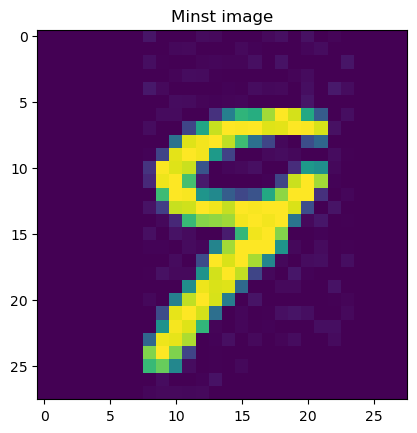

In [50]:
# We initialized our model in the previous section
# Lets now also use the model to pass data through it

# Use the following tensor and pass it through your model from above
# You have to 'reformat' the tensor first
data = torch.randn(size=(5, 1, 28, 28))
# Code here
prep_data=torch.reshape(data,(5,-1)) #as first dim is sample size , we shouldnot alter it. remaining  3 dimensions we flattened into 1 dimension
print(f"the dimension of prep data is : {prep_data.shape}")


# read the image 'mnist_9.jpg' from the downloaded folder with the 'torchvision' python package and pass it through the network
# How does the tensor of the image looks like? Which information is in the different dimensions?

# Code here
inputImage = tv.io.read_image('mnist_9.jpg')  # Read the image using torchvision
print(f"image dimension: {inputImage.shape}") # dim: 1,28,28  channel, height,weidth




# visualize the image from above with matplotlib
import matplotlib.pyplot as plt

# Code here
#as  matploitlib expects height,width and channel we need to reshape
#image=torch.reshape(inputImage, (28,28,1)) #this is bad idea. good is flip position using permute
image=inputImage.permute(1,2,0) #changing from C,H,W to H,W,C
imageplot=plt.imshow(image)
plt.title('Minst image')
plt.show()



## PyTorch Neural Network Example Implementation

In [ ]:
# This is only the application of your defined model
# You can use the following method to train your model and check its accuracy. You can also use parts of the code below for the following practicals.
# Just execute this box and it uses the predefined model from the previous task to run a training procedure. The variable name of the model must be 'model' (or change it accordingly).
# ATTENTION: No worries if you don't understand the implementation. This is just for showing you how your defined model performs in terms of accuracy.

# Refine your model multiple times and see how the different models perform in terms of accuracy.

# We use the MNIST dataset to set the model
import torchvision
import torchvision.transforms as transforms
import tqdm

def load_mnist_data(root_path='./data', batch_size=4):
    transform = transforms.Compose(
        [transforms.ToTensor(),
        transforms.Normalize((0.5), (0.5))]
    )

    trainset = torchvision.datasets.MNIST(root=root_path, train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

    testset = torchvision.datasets.MNIST(root=root_path, train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

    return trainloader  , testloader


def train_model(model, batch_size: int = 4, epochs: int = 10):
    # we only consider the mnist train data for this example
    train_loader, _ = load_mnist_data(root_path='./data', batch_size=batch_size)

    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

    model = model.to(device=device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        running_loss = 0.0
        running_accuracy = []
        for imgs, targets in tqdm.tqdm(train_loader, desc=f'Training iteration {epoch + 1}'):
            imgs, targets = imgs.to(device=device), targets.to(device=device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(imgs.reshape(imgs.shape[0], -1))
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()

            # Calculate the Accuracy (how many of all samples are correctly classified?)
            max_outputs = torch.max(outputs, dim=1).indices
            accuracy = (max_outputs.detach() == targets.detach()).to(dtype=torch.float32).mean()
            running_accuracy.append(accuracy)
    
        print(f'Epoch {epoch + 1} finished with loss: {running_loss / len(train_loader):.3f} and accuracy {torch.tensor(running_accuracy).mean():.3f}')


# Run the model training with the name of your model variable, in this case 'model'
train_model(model=model, batch_size=4, epochs=10)

#observation of accuracy and loss after training the model
'''
                    #first model with only three layers and around 32 max neurons in hidden layer
in first epoch the loss is around 0.912 and the accuracy is around 0.678.
In the following epochs, the loss decreases and the accuracy increases, which indicates that the model is learning and improving its performance on the training data.
 By the end of the 10 epochs the accuracy was already around 0,798 and loss was 0.630. we see improvements with each epochs but final performance is still not 
 satisfactory

                  #second model with 4 layers and much more neurons in between layer
start --> accuracy:0,889            loss: 0,351             #remarks: very impressive from first epoch in comparision to first model
end   --> accuracy: 0,969           loss: 0,112            #improvement with time. final stats are impressive
'''

Training iteration 1: 100%|██████████| 15000/15000 [00:42<00:00, 353.73it/s]


Epoch 1 finished with loss: 0.351 and accuracy 0.889


Training iteration 2: 100%|██████████| 15000/15000 [00:41<00:00, 362.33it/s]


Epoch 2 finished with loss: 0.191 and accuracy 0.944


Training iteration 3: 100%|██████████| 15000/15000 [00:42<00:00, 350.08it/s]


...

Training iteration 9: 100%|██████████| 15000/15000 [00:58<00:00, 255.33it/s]


Epoch 9 finished with loss: 0.111 and accuracy 0.969


Training iteration 10: 100%|██████████| 15000/15000 [01:02<00:00, 240.55it/s]

Epoch 10 finished with loss: 0.112 and accuracy 0.969


'\nin first epoch the loss is around 0.5 and the accuracy is around 0.85, which means that the model is able to classify the images correctly with a good accuracy.\nIn the following epochs, the loss decreases and the accuracy increases, which indicates that the model is learning and improving its performance on the training data.\n By the end of the 5 epochs the accuracy was already around 0,905 which seems to be a good result for this simple model. However, the accuracy can be further improved by adding more hidden layers, \n increasing the number of neurons in the hidden layers, or using different activation functions.\n\n'